In [1]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_parquet("a.parquet/a.parquet")
df

,id,title,text,categories
0,49495844,A & B High Performance Firearms,A & B High Performance Firearms was a competit...,"[Defunct firearms manufacturers, Defunct manuf..."
1,3579086,A & C Black,A & C Black is a British book publishing compa...,"[Encyclopædia Britannica, Ornithological publi..."
2,62397582,A & F Harvey Brothers,"A & F Harvey Brothers, first Spinning Cotton M...",[Cotton mills]
3,15547032,A & G Price,A & G Price Limited is an engineering firm and...,"[Locomotive manufacturers of New Zealand, Tham..."
4,8021609,A & M Karagheusian,thumb|right|238px|A portion of the Karagheusia...,"[1904 establishments in the United States, Arm..."
...,...,...,...,...
442721,73426511,A‘ea‘e (group),A‘ea‘e is a Hawaiian music group composed of K...,"[Hawaiian music, 2022 in music]"
442722,15845764,A∞-operad,In the theory of operads in algebra and algebr...,"[Abstract algebra, Algebraic topology]"
442723,15156877,A♭ (musical note),A (A-flat; also called la bémol) is the ninth ...,[Musical notes]
442724,2994338,A♯ (Axiom),A♯ (pronounced: A sharp) is an object-oriented...,"[Functional languages, Discontinued programmin..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442726 entries, 0 to 442725
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          442726 non-null  object
 1   title       442726 non-null  object
 2   text        442726 non-null  object
 3   categories  442726 non-null  object
dtypes: object(4)
memory usage: 13.5+ MB


In [4]:
df.sample(5)

,id,title,text,categories
109280,12890614,Aindrias Ó Caoimh (attorney general),Aindrias Ó Caoimh (4 October 1912 – 30 Decembe...,"[1912 births, 1994 deaths, Attorneys General o..."
205365,30495112,Alugolla (7°5'N 80°28'E),Alugolla is a village in Sri Lanka. It is loca...,[Populated places in Kandy District]
394037,22153495,Atacira,Atacira is a genus of moths of the family Eute...,"[Euteliinae, Noctuoidea genera]"
165126,45102604,Alexandro Pozzer,Alexandro Pozzer (born 21 December 1988) is a ...,"[1988 births, Living people, Brazilian male ha..."
173755,3656948,Algarah,Algarah (also known as Algarah Bazar) is a tow...,[Villages in Kalimpong district]


In [ ]:
df["document"] = ("Title: " + df["title"].astype(str)+ 
                "\nText: " + df["text"].astype(str)+
                "\nCategories: " + df["categories"].astype(str))

In [ ]:
df["document"].iloc[0]

'Title: A & B High Performance Firearms\nText: A & B High Performance Firearms was a competition pistol manufacturer. Products included the "Limited Class" and "Open Class" semi-automatic pistols, both available in .40 S&W; and .45 ACP. A & B sold directly to consumers. ==References== ==External links== Category:Defunct firearms manufacturers Category:Defunct manufacturing companies based in California\nCategories: [\'Defunct firearms manufacturers\'\n \'Defunct manufacturing companies based in California\']'

In [ ]:
df["doc_len"]=df["document"].str.len()
df["doc_len"].describe()

count    442726.000000
mean       3571.919356
std        6019.120565
min          33.000000
25%         859.000000
50%        1891.000000
75%        3909.000000
max      257785.000000
Name: doc_len, dtype: float64

In [ ]:
df.columns

Index(['id', 'title', 'text', 'categories', 'document', 'doc_len'], dtype='object')

In [ ]:
df.sort_values(by= "doc_len",ascending=False)[["title","doc_len"]].head()

,title,doc_len
387124,Assistant Secretary of Defense for Homeland De...,257785
231782,Amusement Today,230993
334835,Architecture of Liverpool,227170
250439,Andreas Hillgruber,199527
111589,Aircraft in fiction,184947


In [ ]:
print(df["text"].iloc[0])
print("\nLength:", len(df["text"].iloc[0]))

A & B High Performance Firearms was a competition pistol manufacturer. Products included the "Limited Class" and "Open Class" semi-automatic pistols, both available in .40 S&W; and .45 ACP. A & B sold directly to consumers. ==References== ==External links== Category:Defunct firearms manufacturers Category:Defunct manufacturing companies based in California

Length: 358


In [ ]:
df["text"].str.len().describe()

count    442726.000000
mean       3346.942158
std        5968.569487
min           0.000000
25%         682.000000
50%        1654.000000
75%        3630.000000
max      257681.000000
Name: text, dtype: float64

In [ ]:
df["text"].str.len().quantile([0.5,0.75,0.9,0.95,0.99])

0.50     1654.00
0.75     3630.00
0.90     7424.50
0.95    11598.00
0.99    28070.75
Name: text, dtype: float64

In [ ]:
df["doc_len"].iloc[0]

np.int64(505)

In [ ]:
len(df["text"].iloc[0])

358

In [ ]:
print(df["document"].iloc[0][:1000])

Title: A & B High Performance Firearms
Text: A & B High Performance Firearms was a competition pistol manufacturer. Products included the "Limited Class" and "Open Class" semi-automatic pistols, both available in .40 S&W; and .45 ACP. A & B sold directly to consumers. ==References== ==External links== Category:Defunct firearms manufacturers Category:Defunct manufacturing companies based in California
Categories: ['Defunct firearms manufacturers'
 'Defunct manufacturing companies based in California']


In [ ]:
len(df["document"].iloc[0])

505

## character based chunking 


In [ ]:

from langchain_text_splitters import CharacterTextSplitter

splitter = CharacterTextSplitter(chunk_size=1000,chunk_overlap=200)

doc = df["document"].iloc[0]

chunks = splitter.split_text(doc)

print("Number of chunks:", len(chunks))

print("\nChunk 1:\n")
print(chunks[0])

Number of chunks: 1

Chunk 1:

Title: A & B High Performance Firearms
Text: A & B High Performance Firearms was a competition pistol manufacturer. Products included the "Limited Class" and "Open Class" semi-automatic pistols, both available in .40 S&W; and .45 ACP. A & B sold directly to consumers. ==References== ==External links== Category:Defunct firearms manufacturers Category:Defunct manufacturing companies based in California
Categories: ['Defunct firearms manufacturers'
 'Defunct manufacturing companies based in California']


In [ ]:
long_doc_idx = df["document"].str.len().idxmax()

print("Index:", long_doc_idx)
print("Length:", len(df["document"].iloc[long_doc_idx]))

Index: 387124
Length: 257785


In [ ]:
splitter = CharacterTextSplitter(chunk_size=1000,chunk_overlap=200)

doc1=df["document"].iloc[long_doc_idx]
chunks = splitter.split_text(doc1)

print("Number of chunks:", len(chunks))

print("\nChunk 1:\n")
print(chunks[0])

Number of chunks: 1

Chunk 1:

Title: Assistant Secretary of Defense for Homeland Defense and Hemispheric Affairs
Text: The Assistant Secretary of Defense for Homeland Defense and Hemispheric Affairs, or ASD (HD-HA), is responsible for the supervision of DoD homeland defense activities, defense support of civil authorities, and cyber affairs for the Department of Defense. The position was established by the National Defense Authorization Act for Fiscal Year 2003 (P.L. 107-314, passed 2 December 2002). In particular, the ASD (HD&GS;) is responsible for homeland preparedness, oversight of the two combatant commands that cover North and South America, and the transfer of technologies to homeland security use, pursuant to Section 1401 of the 2003 DOD Authorization Act. The ASD (HD&GS;) reports to the Under Secretary of Defense for Policy. == Precedent == At the end of the Eisenhower administration, a wide-ranging federal reorganization (Reorganization Plan No. 1 of 1958) transferred to the

here for it is not being chunked bcoz the splitter couldnt find appropriate seperator so it just dumped everything into a single chunk 

## recursive chunking

In [ ]:
# from langchain_text_splitters import RecursiveCharacterTextSplitter

# splitter = RecursiveCharacterTextSplitter(
#     chunk_size=1000,
#     chunk_overlap=200
# )

# chunks = splitter.split_text(doc1)

# print("Number of chunks:", len(chunks))
# print("First chunk length:", len(chunks[0]))
# print("Second chunk length:", len(chunks[1]))

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=750,
    chunk_overlap=150
)

all_chunks = []


for _, row in df.head(1000).iterrows():

    title = row["title"]
    text = row["text"]

    text_chunks = splitter.split_text(text)

    for chunk in text_chunks:

        chunk_with_title = (
            f"Title: {title}\n\n"
            f"{chunk}"
        )

        all_chunks.append(chunk_with_title)

In [ ]:
# for i in range(5):
#     print(f"\nChunk {i}")
#     print("-"*50)
#     print(chunks[i][:300])
#     print("Length:", len(chunks[i]))

for i in range(5):
    print(f"\nChunk {i}")
    print("-"*50)
    print(all_chunks[i][:300])
    print("Length:", len(all_chunks[i]))


Chunk 0
--------------------------------------------------
Title: A & B High Performance Firearms

A & B High Performance Firearms was a competition pistol manufacturer. Products included the "Limited Class" and "Open Class" semi-automatic pistols, both available in .40 S&W; and .45 ACP. A & B sold directly to consumers. ==References== ==External links== Ca
Length: 398

Chunk 1
--------------------------------------------------
Title: A & C Black

A & C Black is a British book publishing company, owned since 2002 by Bloomsbury Publishing. The company is noted for publishing Who's Who since 1849 and the Encyclopedia Britannica between 1827 and 1903. It offers a wide variety of books in fiction and nonfiction, and has publis
Length: 769

Chunk 2
--------------------------------------------------
Title: A & C Black

firm published the seventh, eighth and ninth editions of the Encyclopædia Britannica. This was purchased from Archibald Constable after his company's failure to publish the s

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

In [ ]:
sample_chunks = all_chunks[:3]
embeddings = model.encode(sample_chunks)

print(embeddings.shape)

(3, 384)


In [ ]:
sample_docs = df["document"].head(1000).tolist()

all_chunks1 = []

for doc in sample_docs:
    all_chunks1.extend(splitter.split_text(doc))

print(len(all_chunks1))

7820


In [ ]:
chunk_embeddings = model.encode(
    all_chunks,
    show_progress_bar=True
)

print(chunk_embeddings.shape)

Batches: 100%|██████████| 190/190 [06:06<00:00,  1.93s/it]

(6055, 384)


In [ ]:
# import faiss 

# dimension = chunk_embeddings.shape[1]

# index=faiss.IndexFlatL2(dimension)

# index.add(np.array(chunk_embeddings).astype("float32"))

# print(index.ntotal)

import faiss

chunk_embeddings = np.array(
    chunk_embeddings,
    dtype="float32"
)

# Normalize embeddings
faiss.normalize_L2(chunk_embeddings)

dimension = chunk_embeddings.shape[1]

# Inner Product index
index = faiss.IndexFlatIP(dimension)

index.add(chunk_embeddings)

print(index.ntotal)

6055


In [ ]:
print(len(all_chunks))
print(chunk_embeddings.shape)
print(index.ntotal)

6055
(6055, 384)
6055


In [ ]:
print(all_chunks[0])
print("-"*100)
print(all_chunks[1])

Title: A & B High Performance Firearms

A & B High Performance Firearms was a competition pistol manufacturer. Products included the "Limited Class" and "Open Class" semi-automatic pistols, both available in .40 S&W; and .45 ACP. A & B sold directly to consumers. ==References== ==External links== Category:Defunct firearms manufacturers Category:Defunct manufacturing companies based in California
----------------------------------------------------------------------------------------------------
Title: A & C Black

A & C Black is a British book publishing company, owned since 2002 by Bloomsbury Publishing. The company is noted for publishing Who's Who since 1849 and the Encyclopedia Britannica between 1827 and 1903. It offers a wide variety of books in fiction and nonfiction, and has published popular travel guides, novels, and science books. ==History== The firm was founded in 1807 by Charles and Adam Black in Edinburgh. In 1851, the company purchased the copyrights to Sir Walter Scott

In [ ]:
print(chunk_embeddings.shape)
print(dimension)

(6055, 384)
384


In [ ]:
print(len(all_chunks))
print(len(df))
print(index.ntotal)

6055
442726
6055


a.parquet
  442,726 documents
         │
         ├── You selected first 1000 docs
         │
         ▼
     6233 chunks
         ▼
     6233 embeddings
         ▼
     FAISS index

In [ ]:
query="football clubs in Greece"

query_embedding=model.encode([query])

print(query_embedding.shape)

(1, 384)


In [ ]:
# D, I = index.search(
#     query_embedding.astype("float32"),
#     k=5
# )

# print("Indices:")
# print(I)

# print("\nDistances:")
# print(D)

# def search(query, k=3):
#     query_embedding = model.encode([query])

#     D, I = index.search(
#         query_embedding.astype("float32"),
#         k
#     )

#     print(f"\nQUERY: {query}")

#     for rank, idx in enumerate(I[0], start=1):
#         print(f"\nResult {rank}")
#         print("-"*80)
#         print(all_chunks[idx][:500])

def search(query, k=3):

    # query_embedding = model.encode([query])

    # D, I = index.search(
    #     query_embedding.astype("float32"),
    #     k
    # )
    
    query_embedding = model.encode([query])

    query_embedding = np.array(
        query_embedding,
        dtype="float32"
    )

    faiss.normalize_L2(query_embedding)

    D, I = index.search(
        query_embedding,
        k
    )

    results = [all_chunks[idx] for idx in I[0]]

    return results,D[0]

In [ ]:
# for rank, idx in enumerate(I[0], start=1):
#     print(f"\n{'='*80}")
#     print(f"Result {rank}")
#     print(f"{'='*80}")

#     print(all_chunks[idx][:1000])

In [ ]:
search("assistant secretary of defense")
search("competition pistol manufacturer")
search("greek financial crisis")
search("football club")

(['Title: A Championship\n\nCup ==References== Category:2008 establishments in Ireland 3 Ire Category:Sports leagues established in 2008 Ire Category:Summer association football leagues',
  "Title: A Championship\n\nPark Riverside Park Aisling-Annacotty Grounds 2008 2010–11 Mervue United Galway Fahy's Field 2008 St Patrick's Athletic A Inchicore Richmond Park 2008–11 Salthill Devon Salthill Drom Soccer Park 2008–09 Shamrock Rovers A Drumcondra Tallaght Tolka Park Tallaght Stadium 2008–11 Shelbourne A Drumcondra Tolka Park 2010 Sligo Rovers A Sligo Showgrounds Sligo IT Grounds 2008–11 Sporting Fingal A Fingal ALSAA Sports Complex 2009–10 Tralee Dynamos Tralee Cahermoneen 2009–11 Tullamore Town Tullamore Leah Victoria Park 2008–10 UCD A Belfield UCD Bowl 2008 2009–11 ===Notes=== ==See also== * 2010 A Championship Cup ==References== Category:2008 establishments in Ireland 3 Ire Category:Sports leagues established in 2008 Ire Category:Summer association",
  'Title: A Championship\n\nA UCD 

In [ ]:
search("A & B High Performance Firearms")
search("Assistant Secretary of Defense for Homeland Defense")
search("Greek financial crisis")
search("A Blast film")

(['Title: A Blast\n\nvillage to get money from a construction company, abandon her loving but constantly cheating and absent husband and their three children, coming to unreconcilable clashes with her always passive father, her half-crazy sister and her fascist brother-in-law. Bits of her rogue present are constantly interwoven with the days of her brighter, full of potential and sexually flourishing love past, creating a dazzling portrait of a woman and a country breaking into pieces. ==Production== A Blast was first presented as an in development project by Homemade Films and producer Maria Drandaki at the Cinelink of the Sarajevo Film Festival 2012 where it was awarded with the Eurimages Co-production Development Award. German producer Titus Kreyenberg and',
  "Title: A Blast\n\nA Blast (), is a 2014 film directed by Syllas Tzoumerkas about a woman's disillusionment and revolt in the frame of the Greek financial crisis. The film stars Angeliki Papoulia, Vassilis Doganis, Maria Filin

In [ ]:
query = input("Enter your question: ")

results, scores = search(query, k=5)

for i, (score, chunk) in enumerate(zip(scores, results)):
    print(f"\nRank {i+1}")
    print("Score:", score)  
    print(chunk[:500])

context = "\n\n".join(results)

print(context[:1000])


Rank 1
Score: 0.6084582
Title: A & B High Performance Firearms

A & B High Performance Firearms was a competition pistol manufacturer. Products included the "Limited Class" and "Open Class" semi-automatic pistols, both available in .40 S&W; and .45 ACP. A & B sold directly to consumers. ==References== ==External links== Category:Defunct firearms manufacturers Category:Defunct manufacturing companies based in California

Rank 2
Score: 0.35298732
Title: A & G Price

after being put into liquidation in 2017. 31 October 2018 * * Category:Locomotive manufacturers of New Zealand Category:Thames-Coromandel District Category:Vehicle manufacturing companies established in 1868 Category:New Zealand companies established in 1868

Rank 3
Score: 0.34818316
Title: A & G Price

Society (Stored offsite) * TR 171 (TR 730 TMS) - Museum of Transport & Technology * V 148 - Canterbury Steam Preservation Society * WAB 800 -Glenbrook Vintage Railway * WF 392 - boiler preserved at Don River Railway, Tasmania

In [ ]:
prompt = f"""
Answer the question using the context. If the context does not contain the answer, say you don't know .

Context:
{context}

Question:
{query}

Answer:
"""

In [ ]:
from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0"
)
messages = [
    {
        "role": "user",
        "content": prompt
    }
]

response = llm(
    messages,
    max_new_tokens=100
)
print(response)
print(response[0]["generated_text"][-1])
print(response[0]["generated_text"][-1]["content"])



Device set to use cpu


[{'generated_text': [{'role': 'user', 'content': '\nAnswer the question using the context. If the context does not contain the answer, say you don\'t know .\n\nContext:\nTitle: A & B High Performance Firearms\n\nA & B High Performance Firearms was a competition pistol manufacturer. Products included the "Limited Class" and "Open Class" semi-automatic pistols, both available in .40 S&W; and .45 ACP. A & B sold directly to consumers. ==References== ==External links== Category:Defunct firearms manufacturers Category:Defunct manufacturing companies based in California\n\nTitle: A & G Price\n\nafter being put into liquidation in 2017. 31 October 2018 * * Category:Locomotive manufacturers of New Zealand Category:Thames-Coromandel District Category:Vehicle manufacturing companies established in 1868 Category:New Zealand companies established in 1868\n\nTitle: A & G Price\n\nSociety (Stored offsite) * TR 171 (TR 730 TMS) - Museum of Transport & Technology * V 148 - Canterbury Steam Preservatio

In [ ]:
eval_set = [

    {
        "query":"competition pistol manufacturer",
        "expected_title":"A & B High Performance Firearms"
    },

    {
        "query":"British publishing company",
        "expected_title":"A & C Black"
    },

    {
        "query":"publisher of Encyclopedia Britannica",
        "expected_title":"A & C Black"
    },

    {
        "query":"Who publishes Who's Who?",
        "expected_title":"A & C Black"
    },

    {
        "query":"semi automatic pistols",
        "expected_title":"A & B High Performance Firearms"
    }
]

In [ ]:
def recall_at_k(eval_set, k=5):

    hits = 0

    for item in eval_set:

        query = item["query"]
        expected = item["expected_title"]

        results, scores = search(query, k)

        found = False

        for chunk in results:

            if f"Title: {expected}" in chunk:
                found = True
                break

        if found:
            hits += 1

    return hits / len(eval_set)

In [ ]:
print(recall_at_k(eval_set, k=1))
print(recall_at_k(eval_set, k=3))
print(recall_at_k(eval_set, k=5))

0.8
1.0
1.0


In [ ]:
def mrr(eval_set, k=10):

    scores = []

    for item in eval_set:

        query = item["query"]
        expected = item["expected_title"]

        results, _ = search(query, k)

        rr = 0

        for rank, chunk in enumerate(results, start=1):

            if f"Title: {expected}" in chunk:
                rr = 1 / rank
                break

        scores.append(rr)

    return sum(scores) / len(scores)

In [ ]:
print("MRR:", mrr(eval_set))

MRR: 0.9


In [ ]:
import time

def evaluate_chunk_size(chunk_size, chunk_overlap_ratio=0.2, sample_docs_df=None, eval_set=None, model=None, k_values=[1, 3, 5]):
    """
    End-to-end evaluation of a given chunk_size.
    
    Parameters:
        chunk_size: int — the chunk size to test
        chunk_overlap_ratio: float — overlap as a fraction of chunk_size (default 20%)
        sample_docs_df: DataFrame — subset of df to chunk (should have 'title' and 'text' columns)
        eval_set: list of dicts — each with 'query' and 'expected_title'
        model: SentenceTransformer model
        k_values: list of k values for recall@k
    
    Returns:
        dict with chunk_size, chunk_overlap, num_chunks, avg_chunk_len,
        recall@k for each k, mrr, embedding_time
    """
    chunk_overlap = int(chunk_size * chunk_overlap_ratio)
    
    # --- 1. Chunk ---
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    
    all_chunks_local = []
    for _, row in sample_docs_df.iterrows():
        title = row["title"]
        text = row["text"]
        text_chunks = splitter.split_text(text)
        for chunk in text_chunks:
            all_chunks_local.append(f"Title: {title}\n\n{chunk}")
    
    num_chunks = len(all_chunks_local)
    avg_chunk_len = np.mean([len(c) for c in all_chunks_local])
    
    # --- 2. Embed ---
    start = time.time()
    embeddings = model.encode(all_chunks_local, show_progress_bar=False)
    embed_time = time.time() - start
    
    embeddings = np.array(embeddings, dtype="float32")
    faiss.normalize_L2(embeddings)
    
    # --- 3. Index ---
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension)
    index.add(embeddings)
    
    # --- 4. Search helper (local) ---
    def _search(query, k=5):
        qe = model.encode([query])
        qe = np.array(qe, dtype="float32")
        faiss.normalize_L2(qe)
        D, I = index.search(qe, k)
        results = [all_chunks_local[idx] for idx in I[0]]
        return results, D[0]
    
    # --- 5. Evaluate ---
    max_k = max(k_values)
    
    # Recall@k
    recall_results = {}
    for k in k_values:
        hits = 0
        for item in eval_set:
            results, _ = _search(item["query"], k)
            if any(f"Title: {item['expected_title']}" in chunk for chunk in results):
                hits += 1
        recall_results[f"recall@{k}"] = hits / len(eval_set)
    
    # MRR
    rr_scores = []
    for item in eval_set:
        results, _ = _search(item["query"], max_k)
        rr = 0
        for rank, chunk in enumerate(results, start=1):
            if f"Title: {item['expected_title']}" in chunk:
                rr = 1 / rank
                break
        rr_scores.append(rr)
    mrr_score = np.mean(rr_scores)
    
    return {
        "chunk_size": chunk_size,
        "chunk_overlap": chunk_overlap,
        "num_chunks": num_chunks,
        "avg_chunk_len": round(avg_chunk_len, 1),
        "embedding_time_sec": round(embed_time, 2),
        **recall_results,
        "mrr": round(mrr_score, 4)
    }

In [ ]:
# Chunk sizes to compare
chunk_sizes = [200, 500, 750, 1000, 1500, 2000, 3000]

# Use the same first-1000 docs subset you already used
sample_df = df.head(1000)

results_list = []

for cs in chunk_sizes:
    print(f"Testing chunk_size={cs} ...")
    result = evaluate_chunk_size(
        chunk_size=cs,
        chunk_overlap_ratio=0.2,
        sample_docs_df=sample_df,
        eval_set=eval_set,
        model=model,
        k_values=[1, 3, 5]
    )
    results_list.append(result)
    print(f"  → {result['num_chunks']} chunks | recall@5={result['recall@5']:.2f} | MRR={result['mrr']:.4f} | embed_time={result['embedding_time_sec']}s")

comparison_df = pd.DataFrame(results_list)
print("\n")
comparison_df

Testing chunk_size=200 ...
  → 21985 chunks | recall@5=1.00 | MRR=0.9000 | embed_time=542.39s
Testing chunk_size=500 ...
  → 8940 chunks | recall@5=1.00 | MRR=0.7500 | embed_time=424.28s
Testing chunk_size=750 ...
  → 6055 chunks | recall@5=1.00 | MRR=0.9000 | embed_time=505.56s
Testing chunk_size=1000 ...


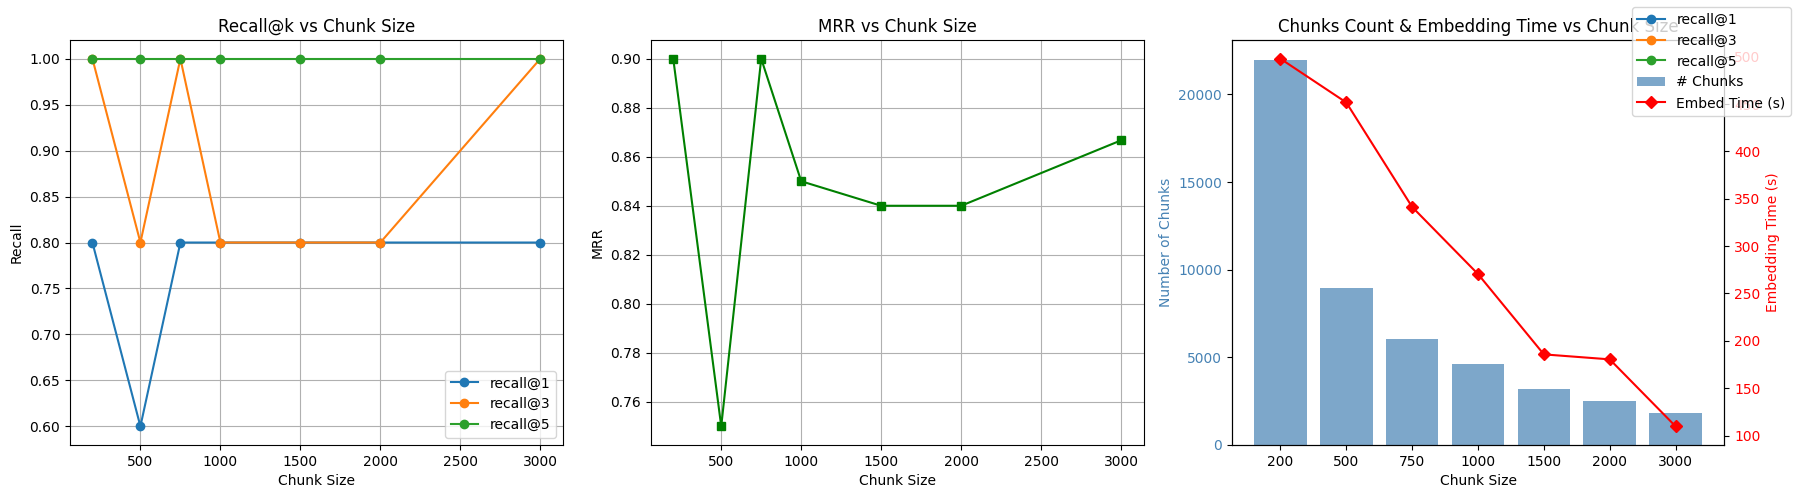

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Recall@k vs chunk_size
for k_col in ["recall@1", "recall@3", "recall@5"]:
    axes[0].plot(comparison_df["chunk_size"], comparison_df[k_col], marker="o", label=k_col)
axes[0].set_xlabel("Chunk Size")
axes[0].set_ylabel("Recall")
axes[0].set_title("Recall@k vs Chunk Size")
axes[0].legend()
axes[0].grid(True)

# Plot 2: MRR vs chunk_size
axes[1].plot(comparison_df["chunk_size"], comparison_df["mrr"], marker="s", color="green")
axes[1].set_xlabel("Chunk Size")
axes[1].set_ylabel("MRR")
axes[1].set_title("MRR vs Chunk Size")
axes[1].grid(True)

# Plot 3: Number of chunks & embedding time vs chunk_size
ax3 = axes[2]
ax3.bar(comparison_df["chunk_size"].astype(str), comparison_df["num_chunks"], color="steelblue", alpha=0.7, label="# Chunks")
ax3.set_xlabel("Chunk Size")
ax3.set_ylabel("Number of Chunks", color="steelblue")
ax3.tick_params(axis="y", labelcolor="steelblue")

ax3b = ax3.twinx()
ax3b.plot(comparison_df["chunk_size"].astype(str), comparison_df["embedding_time_sec"], marker="D", color="red", label="Embed Time (s)")
ax3b.set_ylabel("Embedding Time (s)", color="red")
ax3b.tick_params(axis="y", labelcolor="red")

ax3.set_title("Chunks Count & Embedding Time vs Chunk Size")
fig.legend(loc="upper right")

plt.tight_layout()
plt.show()